In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

SEED = 1989
# random number generator
rng = np.random.default_rng(seed=SEED)

## Generate random samples to perform PCA on

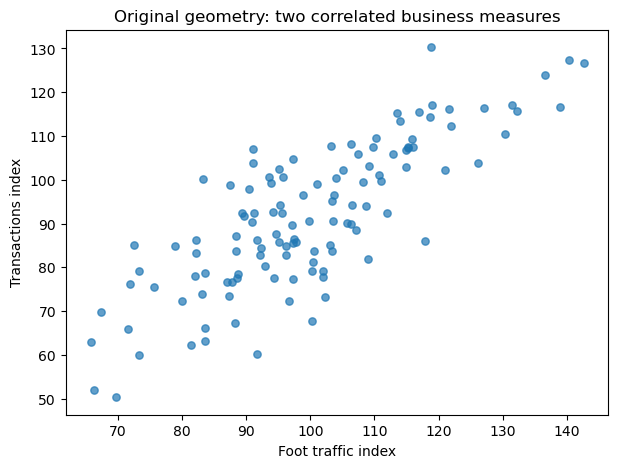

In [2]:
# True Data Generating Process (TDGP)
n = 120
foot_traffic = rng.normal(loc=100, scale=18, size=n)
transactions = 0.82 * foot_traffic + rng.normal(loc=10, scale=10, size=n)
X_small = pd.DataFrame({
    'foot_traffic_index': foot_traffic,
    'transactions_index': transactions
})

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(X_small['foot_traffic_index'], X_small['transactions_index'], s=28, alpha=0.7)
ax.set_title("Original geometry: two correlated business measures")
ax.set_xlabel("Foot traffic index")
ax.set_ylabel("Transactions index")
plt.show()

In [3]:
X_small.describe().T

,count,mean,std,min,25%,50%,75%,max
foot_traffic_index,120.0,99.805128,16.329740,65.725655,89.190290,97.570287,109.808342,142.629460
transactions_index,120.0,91.669341,16.657877,50.325838,79.174753,90.602558,103.837721,130.277197


## Step 1: Standardize the features

In [4]:
means = X_small.mean(axis=0)
stds = X_small.std(axis=0)

Z = (X_small - means) / stds

In [5]:
Z

,foot_traffic_index,transactions_index
0,0.041863,-0.621334
1,-0.290926,-0.355147
2,0.633955,1.074344
3,0.864169,1.312455
4,-0.502306,-0.326550
...,...,...
115,-1.127467,-1.765951
116,-0.768016,-1.093982
117,0.220956,-0.477056
118,-0.680513,-0.787542


## Step 2: Compute the Covariance Matrix

In [6]:
cov_matrix = np.cov(Z.T)
cov_df = pd.DataFrame(cov_matrix, index=Z.columns, columns=Z.columns)
cov_df

,foot_traffic_index,transactions_index
foot_traffic_index,1.000000,0.802983
transactions_index,0.802983,1.000000


## Step 3: Find Eigenvectors and Eigenvalues

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [8]:
# Sort
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

In [9]:
eigenvalues

array([1.80298337, 0.19701663])

In [10]:
eigenvectors

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

In [11]:
# Variance demo
# How much does the first eigenvalue explain variance?
eigenvalues[0] / sum(eigenvalues)

np.float64(0.9014916848752713)

In [12]:
#Vectorize
explained_ratio = eigenvalues / np.sum(eigenvalues)
summary = pd.DataFrame({
    'eigenvalue': eigenvalues,
    'explained_ratio': explained_ratio
}, index = ['PC1', 'PC2']
                      )
summary

,eigenvalue,explained_ratio
PC1,1.802983,0.901492
PC2,0.197017,0.098508


## Step 4: Read the loadings

In [13]:
loadings = pd.DataFrame(eigenvectors,
                        index = Z.columns,
                        columns=['PC1', 'PC2'])
loadings

,PC1,PC2
foot_traffic_index,0.707107,-0.707107
transactions_index,0.707107,0.707107


## Step 5: Project the observations into the component space

In [14]:
scores = Z.to_numpy() @ eigenvectors
scores_df = pd.DataFrame(scores, columns=['PC1', 'PC2'])
scores_df

,PC1,PC2
0,-0.409748,-0.468951
1,-0.456843,-0.045411
2,1.207950,0.311402
3,1.539106,0.316986
4,-0.586090,0.124278
...,...,...
115,-2.045955,-0.451476
116,-1.316631,-0.230493
117,-0.181090,-0.493569
118,-1.038071,-0.075681


## Step 6: Visualize

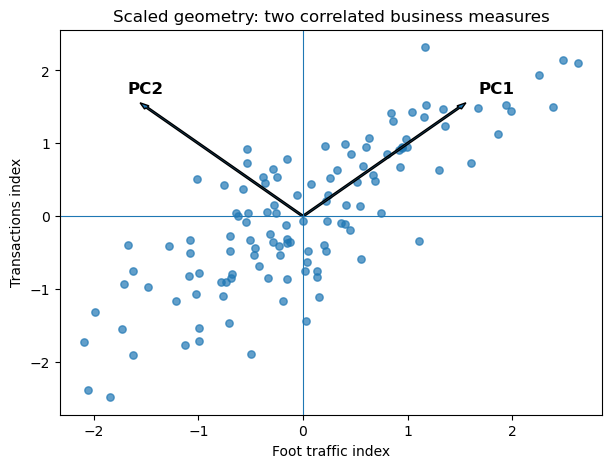

In [15]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(Z.iloc[:,0], Z.iloc[:,1], s=28, alpha=0.7)
ax.set_title("Scaled geometry: two correlated business measures")
ax.set_xlabel("Foot traffic index")
ax.set_ylabel("Transactions index")

origin = np.array([0,0])
scale = 2.2

for idx, label in enumerate(['PC1', 'PC2']):
    vec = eigenvectors[:, idx]
    ax.arrow(origin[0], origin[1], vec[0]*scale, vec[1]*scale,
             width=0.02, length_includes_head=True)
    
    ax.text(vec[0]*scale*1.08, vec[1]*scale*1.08, label, fontsize=12, weight='bold')

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
    
plt.show()

## Scikit version

In [16]:
#Initialize the algo
sk_pca = PCA(n_components = 2)
sk_scores = sk_pca.fit_transform(Z)
sk_scores_df = pd.DataFrame(sk_scores, columns=['PC1', 'PC2'])
sk_scores_df

,PC1,PC2
0,-0.409748,-0.468951
1,-0.456843,-0.045411
2,1.207950,0.311402
3,1.539106,0.316986
4,-0.586090,0.124278
...,...,...
115,-2.045955,-0.451476
116,-1.316631,-0.230493
117,-0.181090,-0.493569
118,-1.038071,-0.075681
